<a href="https://www.kaggle.com/code/masum1834e/mobilenet?scriptVersionId=320469558" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## MobileNet

**MobileNet** is a family of efficient convolutional neural network (CNN) architectures designed for mobile and embedded devices where computation, memory, and power are limited. It was introduced by Google researchers to make deep learning practical on smartphones, IoT devices, and real-time applications.

### Core Idea of MobileNet

Traditional CNNs (like VGGNet or ResNet) use **standard convolutions**, which are computationally expensive.

MobileNet replaces these with a much cheaper operation called: **Depthwise Separable Convolution**

It splits a standard convolution into two steps:

1. Depthwise Convolution
    * Applies **one filter per input channel**
    * Captures spatial features (height & width)
2. Pointwise Convolution (1×1 convolution)
    * Combines outputs across channels
    * Builds feature relationships


**Why This Matters**

Compared to standard convolution:

* **~8–9× fewer computations**
* **Much smaller model size**
* Slight trade-off in accuracy

**Mathematical Insight**

Standard convolution cost:

```
Dk × Dk × M × N × Df × Df
```

Depthwise separable convolution cost:

```
(Dk × Dk × M × Df × Df) + (M × N × Df × Df)
```

Where:

* `Dk` = kernel size
* `M` = input channels
* `N` = output channels
* `Df` = feature map size

This drastically reduces computation.

### MobileNet Architecture

A typical MobileNet model consists of:

* Initial standard convolution layer
* Followed by multiple **depthwise separable convolution blocks**
* Batch normalization + ReLU activation
* Global average pooling
* Fully connected / softmax layer

### Key Hyperparameters

#### Width Multiplier (α)

* Controls number of channels
* Example:

  * α = 1 → full model
  * α = 0.5 → half channels → faster, smaller

#### Resolution Multiplier (ρ)

* Reduces input image size
* Example:

  * 224×224 → 160×160

### Versions of MobileNet

1. **MobileNetV1:** Introduced depthwise separable convolution
2. **MobileNetV2**
    * Introduced:
      * **Inverted residual blocks**
      * **Linear bottlenecks**
    * Better performance & efficiency
3. **MobileNetV3**
    * Uses:
      * Neural architecture search (NAS)
      * Squeeze-and-Excitation (SE)
      * Hard-swish activation
    * Optimized for real-world deployment

[Read More](https://www.geeksforgeeks.org/computer-vision/what-is-mobilenet-v2/)

In [22]:
# Load the pre-trained MobileNet model
import tensorflow as tf
from tensorflow.keras.applications import MobileNet

model = MobileNet(weights='imagenet')

# This loads MobileNet trained on ImageNet (a large dataset of labeled images).

**Parameters and possible values**

| Parameter               | Description                            | Possible values                         |
| ----------------------- | -------------------------------------- | --------------------------------------- |
| `input_shape`           | Shape of input images                  | Tuple like `(224,224,3)`, `(128,128,3)` |
| `alpha`                 | Width multiplier (controls model size) | `0.25`, `0.5`, `0.75`, `1.0`            |
| `depth_multiplier`      | Depthwise convolution multiplier       | Integer, usually `1`                    |
| `dropout`               | Dropout rate before classifier         | Float like `0.001`, `0.2`, `0.5`        |
| `include_top`           | Include final classification layer     | `True` or `False`                       |
| `weights`               | Pretrained weights                     | `'imagenet'`, `None`                    |
| `input_tensor`          | Existing Keras tensor as input         | Tensor object or `None`                 |
| `pooling`               | Pooling mode when `include_top=False`  | `None`, `'avg'`, `'max'`                |
| `classes`               | Number of output classes               | Any positive integer                    |
| `classifier_activation` | Activation for final layer             | `'softmax'`, `None`                     |

**ImageNet**

ImageNet is a massive image dataset used to train and evaluate computer vision models.

It contains:

* Millions of labeled images
* Thousands of object categories
* Human-annotated labels like:
    * cats
    * dogs
    * cars
    * bicycles
    * fruits
    * people

Why it is important

ImageNet became famous because it powered breakthroughs in deep learning and image classification. Many pretrained models in TensorFlow and Keras are trained on ImageNet, including:

* MobileNet
* ResNet
* VGG16
* EfficientNet
* InceptionV3

In [6]:
import numpy as np
from tensorflow.keras.applications.mobilenet import preprocess_input
import cv2

# Load image
image_path = "/kaggle/input/datasets/masum1834e/test-data/dog.jpg"
original_img = cv2.imread(image_path)

# Keep a copy for display
display_img = original_img.copy()

# Convert BGR → RGB
img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# Resize to 224x224
img = cv2.resize(img, (224, 224))

# Convert to array
img = np.array(img)

# Add batch dimension
img = np.expand_dims(img, axis=0)

# Preprocess
img = preprocess_input(img)

In [7]:
predictions = model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [8]:
from tensorflow.keras.applications.mobilenet import preprocess_input, decode_predictions

# Decode results
results = decode_predictions(predictions, top=3)

for r in results[0]:
    print(r)

('n02106166', 'Border_collie', np.float32(0.9147196))
('n02106030', 'collie', np.float32(0.028250115))
('n02113186', 'Cardigan', np.float32(0.02428607))


* **Border Collies** are highly intelligent and highly trainable and are superstars at canine activities such as herding, obedience, and agility.
* **Collies** are famously fond of children and make wonderful family pets.
* The **Cardigan** Welsh Corgi is an intelligent, sturdy herding breed known for its long body, short legs, large rounded ears, and long fox-like tail.

> Because MobileNet simply doesn’t do that. It’s a classifier, not an object detector—so it has no idea where the object is in the image, only what is most likely present.

## Single Shot Detector

In [9]:
import torchvision

# Load pretrained SSD
model = torchvision.models.detection.ssd300_vgg16(pretrained=True)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SSD300_VGG16_Weights.COCO_V1`. You can also use `weights=SSD300_VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:00<00:00, 180MB/s] 


SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

In [16]:
import torchvision.transforms as T
import cv2

# Load image
image_path = "/kaggle/input/datasets/masum1834e/test-data/public.jpg"
img = cv2.imread(image_path)

transform = T.Compose([T.ToTensor()])
img_tensor = transform(img)

In [17]:
# Prediction
output = model([img_tensor])
output

[{'boxes': tensor([[4.4234e+03, 2.2451e+03, 7.1825e+03, 4.9931e+03],
          [1.4384e+03, 2.8895e+03, 4.1425e+03, 5.0241e+03],
          [6.5603e+03, 2.5328e+03, 7.6464e+03, 4.9447e+03],
          [2.4746e+02, 2.4055e+03, 1.8731e+03, 4.7528e+03],
          [1.4727e+03, 2.2011e+03, 2.2471e+03, 3.6627e+03],
          [3.9516e+03, 3.1037e+03, 5.2589e+03, 4.1862e+03],
          [3.0521e+03, 3.2051e+03, 3.7949e+03, 4.1569e+03],
          [1.3751e+03, 3.8474e+03, 1.6512e+03, 4.3894e+03],
          [1.7945e+03, 2.6498e+03, 2.6553e+03, 3.9922e+03],
          [1.4196e+03, 2.5301e+03, 2.8750e+03, 4.7147e+03],
          [2.7355e+03, 3.1464e+03, 3.5810e+03, 4.0562e+03],
          [9.4929e+02, 2.5462e+03, 1.8581e+03, 4.0691e+03],
          [1.7623e+03, 2.4141e+03, 5.8687e+03, 5.0380e+03],
          [1.4366e+03, 2.7401e+03, 2.2899e+03, 4.1494e+03],
          [1.4350e+02, 3.4871e+03, 1.0043e+03, 4.8495e+03],
          [1.6731e+03, 2.3508e+03, 2.6221e+03, 3.4431e+03],
          [2.9318e+03, 1.0902e+

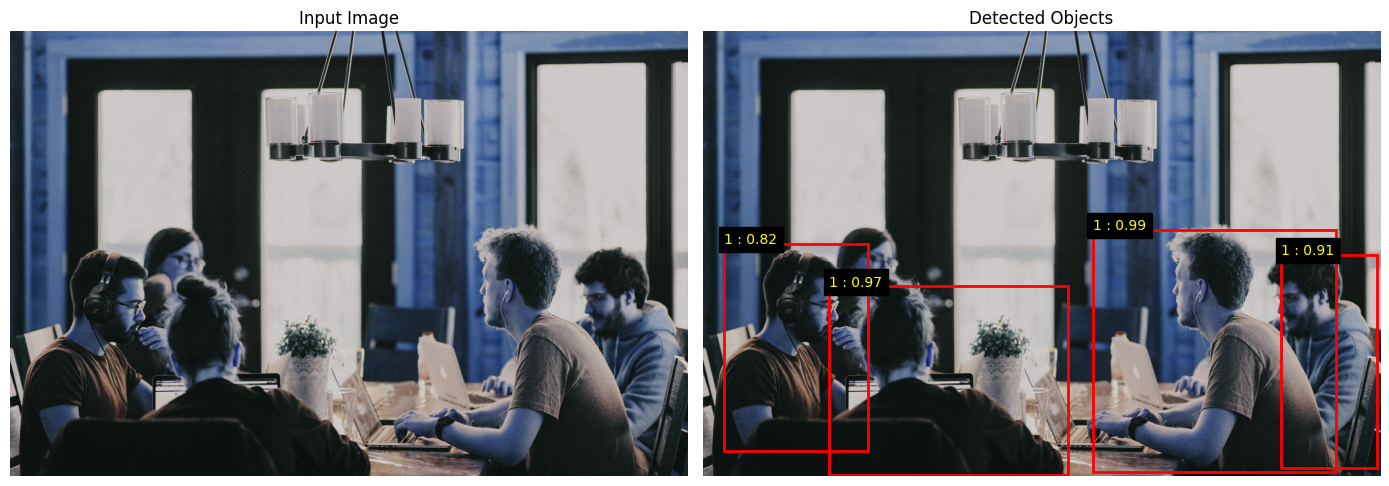

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# Create figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# -------------------------
# LEFT: Original Image
# -------------------------
ax[0].imshow(img)
ax[0].set_title("Input Image")
ax[0].axis("off")

# -------------------------
# RIGHT: Output Image
# -------------------------
ax[1].imshow(img)
ax[1].set_title("Detected Objects")
ax[1].axis("off")

# Draw bounding boxes
threshold = 0.5

for box, score, label in zip(output[0]['boxes'],
                             output[0]['scores'],
                             output[0]['labels']):

    if score > threshold:

        x1, y1, x2, y2 = box.tolist()

        # Create rectangle
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax[1].add_patch(rect)

        # Add label + confidence
        ax[1].text(
            x1,
            y1 - 5,
            f"{label.item()} : {score:.2f}",
            color='yellow',
            fontsize=10,
            backgroundcolor='black'
        )

plt.tight_layout()
plt.show()

## Mobilenet SSD

In [2]:
import torchvision

# SSD Detector (PyTorch)
ssd_model = torchvision.models.detection.ssd300_vgg16(pretrained=True)
ssd_model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SSD300_VGG16_Weights.COCO_V1`. You can also use `weights=SSD300_VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

In [3]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNet

# MobileNet Classifier (TensorFlow)
mobilenet_model = MobileNet(weights='imagenet')

2026-05-19 03:30:25.092885: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
import cv2

image_path = "/kaggle/input/datasets/masum1834e/test-data/public.jpg"

# OpenCV loads as BGR
original_img = cv2.imread(image_path)

# Keep display copy
display_img = original_img.copy()

In [5]:
# SSD OBJECT DETECTION
import torchvision.transforms as T
import torch

transform = T.Compose([
    T.ToTensor()
])

img_tensor = transform(original_img)

with torch.no_grad():
    outputs = ssd_model([img_tensor])

# Get detections
boxes = outputs[0]['boxes']
scores = outputs[0]['scores']
labels = outputs[0]['labels']

In [6]:
# PROCESS DETECTIONS
import numpy as np
from tensorflow.keras.applications.mobilenet import (
    preprocess_input,
    decode_predictions
)

# from PIL import Image
for i in range(len(boxes)):

    score = scores[i].item()

    # Confidence threshold
    if score < 0.50:
        continue

    # Bounding box
    x1, y1, x2, y2 = boxes[i].int().tolist()

    # Crop detected object
    crop = original_img[y1:y2, x1:x2]

    # Skip invalid crops
    if crop.size == 0:
        continue

    # PREPARE FOR MOBILENET

    # Convert BGR → RGB
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

    # Resize for MobileNet
    crop_resized = cv2.resize(crop_rgb, (224, 224))

    # Convert to array
    crop_array = np.array(crop_resized)

    # Add batch dimension
    crop_array = np.expand_dims(crop_array, axis=0)

    # Preprocess
    crop_array = preprocess_input(crop_array)

    # MOBILENET CLASSIFICATION

    predictions = mobilenet_model.predict(crop_array)

    decoded = decode_predictions(predictions, top=1)

    class_name = decoded[0][0][1]
    confidence = decoded[0][0][2]

    # DRAW RESULTS

    label_text = f"{class_name}: {confidence:.2f}"

    cv2.rectangle(display_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    cv2.putText(
        display_img,
        label_text,
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

    print(f"Detected object: {label_text}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 770ms/step
Detected object: stethoscope: 0.10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Detected object: laptop: 0.12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Detected object: ski_mask: 0.17
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Detected object: banjo: 0.47


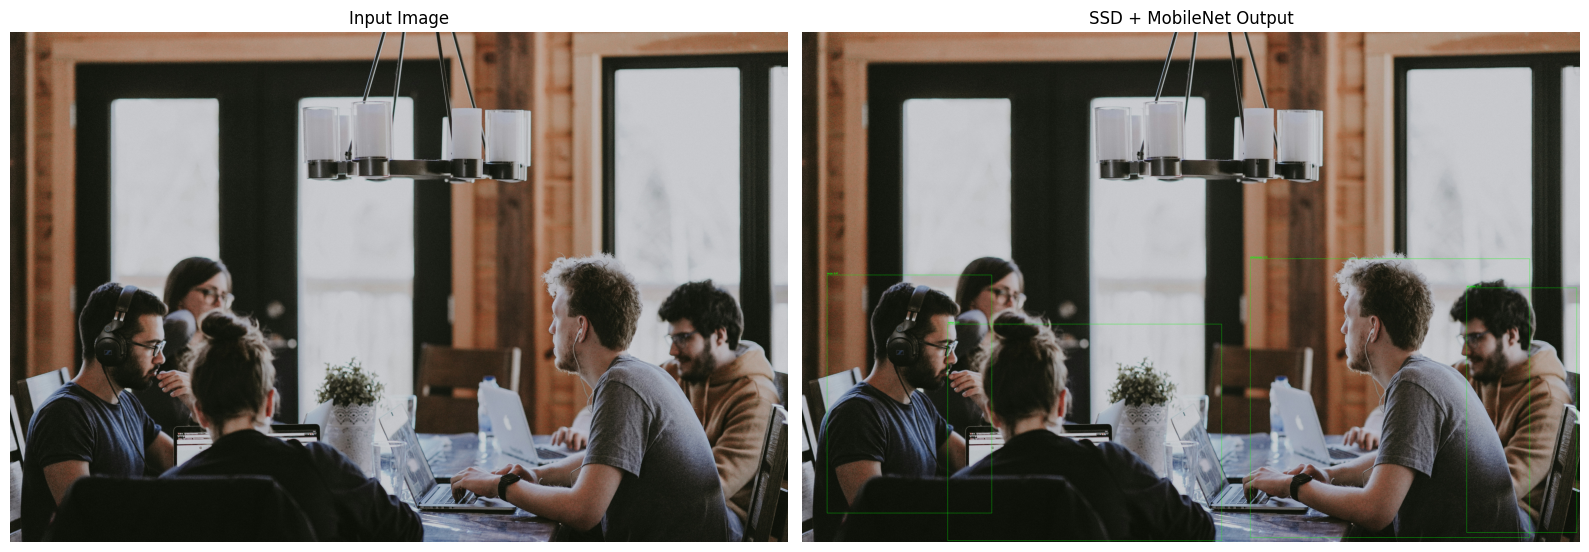

In [7]:
import matplotlib.pyplot as plt

# Convert BGR → RGB
input_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
output_rgb = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)

# Create figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Original image
ax[0].imshow(input_rgb)
ax[0].set_title("Input Image")
ax[0].axis("off")

# Output image
ax[1].imshow(output_rgb)
ax[1].set_title("SSD + MobileNet Output")
ax[1].axis("off")

plt.tight_layout()
plt.show()